In [1]:
from google.colab import files
uploaded = files.upload()

Saving netflix_customers.csv to netflix_customers.csv


In [2]:
import pandas as pd

df = pd.read_csv("netflix_customers.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,Crypto,2,0.13,Action


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   payment_method          5000 non-null   object 
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(3), object(7)
memory usage: 507.9+ KB


In [5]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,5.000000,98.420000


The average user age is around 44 years, indicating a mature user base.

Watch hours vary significantly, showing both casual and heavy viewers.

Monthly fees range between Basic and Premium tiers.

The average number of profiles per account is approximately 3.

Some extreme values suggests the presence of outliers

Age Distribution:

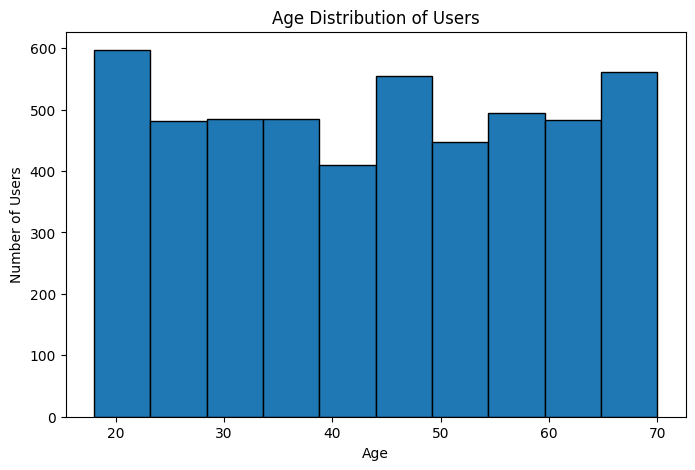

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=10, edgecolor='black')

plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Age Distribution of Users")

plt.show()

Insight : **Age Distribution of Users**

The users are distributed across a wide age range from 18 to 70 years.

No single age band overwhelmingly dominates the dataset.

This indicates that the platform caters to a diverse demographic.

The relatively uniform distribution suggests balanced user representation.

Gender
Breakdown

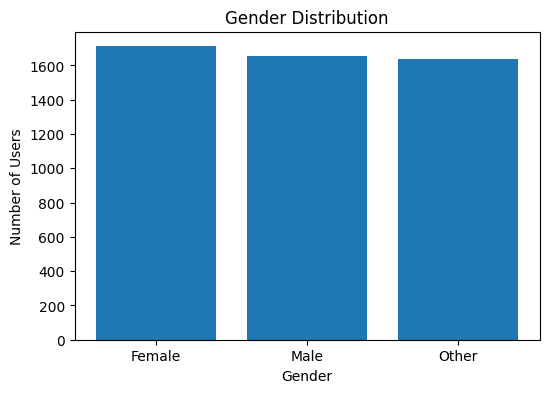

In [8]:
import matplotlib.pyplot as plt

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values)

plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.title("Gender Distribution")

plt.show()

The dataset shows a nearly balanced distribution across gender categories.

Male, Female, and other users are represented in comparable proportions.

This balance enables unbiased behavioral and preference analysis.

The platform appears to attract a diverse user base.

Visualization – Subscription Type Distribution

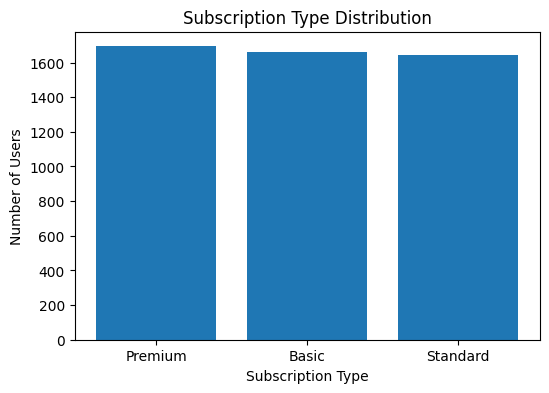

In [9]:
import matplotlib.pyplot as plt

sub_counts = df['subscription_type'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sub_counts.index, sub_counts.values)

plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")
plt.title("Subscription Type Distribution")

plt.show()

The dataset shows a relatively uniform distribution across subscription tiers.

Basic, Standard, and Premium plans have comparable user counts.

This suggests balanced customer adoption across pricing levels.

No extreme skewness toward a single subscription tier is observed.

Favorite Genre Distribution

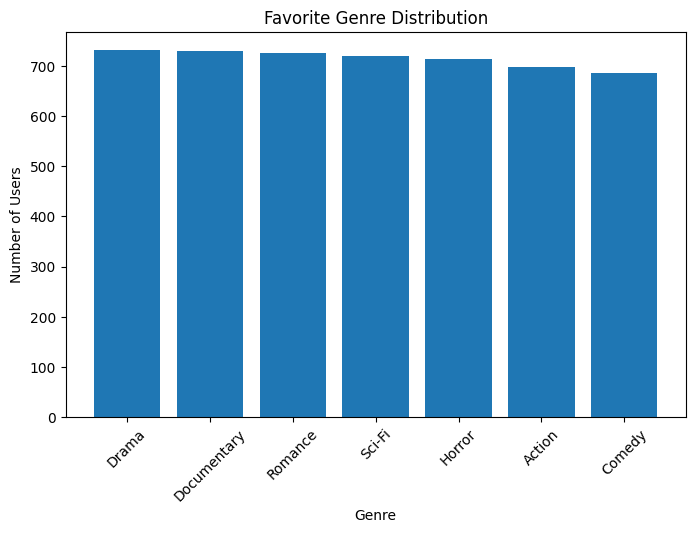

In [10]:
genre_counts = df['favorite_genre'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(genre_counts.index, genre_counts.values)

plt.xlabel("Genre")
plt.ylabel("Number of Users")
plt.title("Favorite Genre Distribution")

plt.xticks(rotation=45)
plt.show()

User preferences are distributed across multiple genres.

No single genre overwhelmingly dominates the dataset.

This suggests varied viewer interests and diverse content consumption.

The platform appears to cater to a broad range of entertainment tastes.

Watch Time
Patterns

<Figure size 800x500 with 0 Axes>

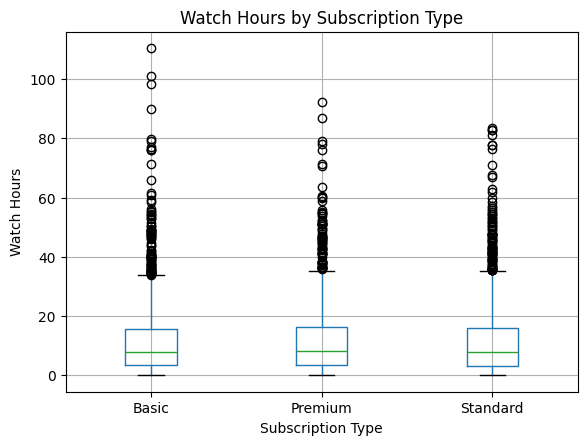

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column='watch_hours', by='subscription_type')

plt.xlabel("Subscription Type")
plt.ylabel("Watch Hours")
plt.title("Watch Hours by Subscription Type")

plt.suptitle("")  # removes extra default title
plt.show()

**Insight – Watch Hours by Subscription Type**

Watch hour distributions across subscription tiers appear broadly similar.

Median watch hours do not show extreme separation between plans.

All subscription types contain high-usage outliers.

This suggests overlapping viewing behavior among user tiers.

**Account Sharing Trends**

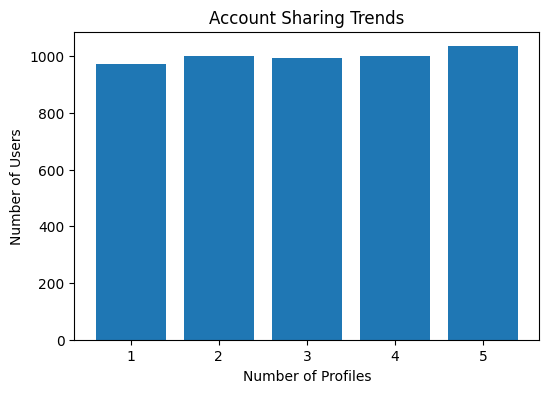

In [12]:
share_counts = df['number_of_profiles'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(share_counts.index, share_counts.values)

plt.xlabel("Number of Profiles")
plt.ylabel("Number of Users")
plt.title("Account Sharing Trends")

plt.show()

**Insight – Account Sharing Trends**

The distribution of profiles per account highlights sharing behavior.

Higher profile counts indicate multi-user accounts.

This suggests collaborative or family-based usage patterns.

**Gender vs Genre**

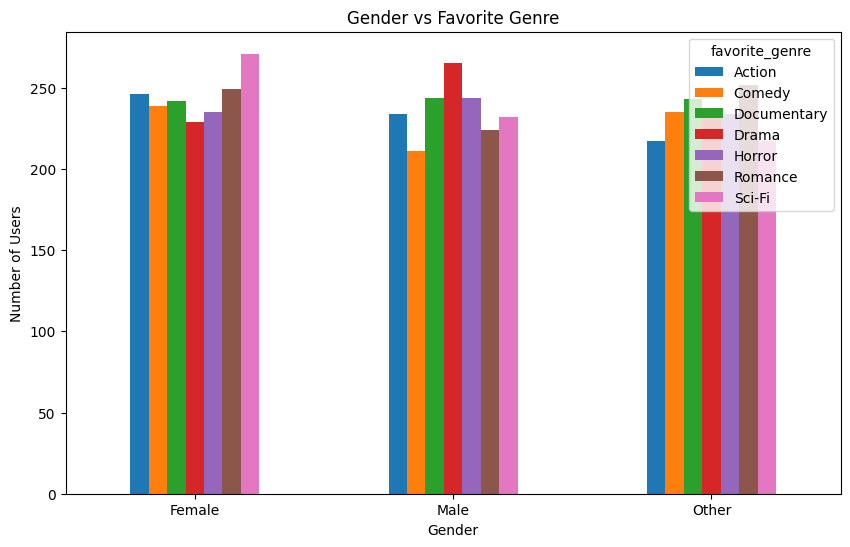

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

genre_gender = pd.crosstab(df['gender'], df['favorite_genre'])

genre_gender.plot(kind='bar', figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.title("Gender vs Favorite Genre")

plt.xticks(rotation=0)
plt.show()

The analysis of genre preferences across gender categories reveals noticeable variations in viewing behavior.

Male users show relatively stronger representation in Action-oriented genres.

Female users display higher inclination toward Drama and Romance genres.

Users categorized as "Other" demonstrate fairly balanced genre preferences.

Age vs Genre

In [14]:
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 25, 40, 60, 100],
                         labels=['Under 25', '25-40', '40-60', '60+'])

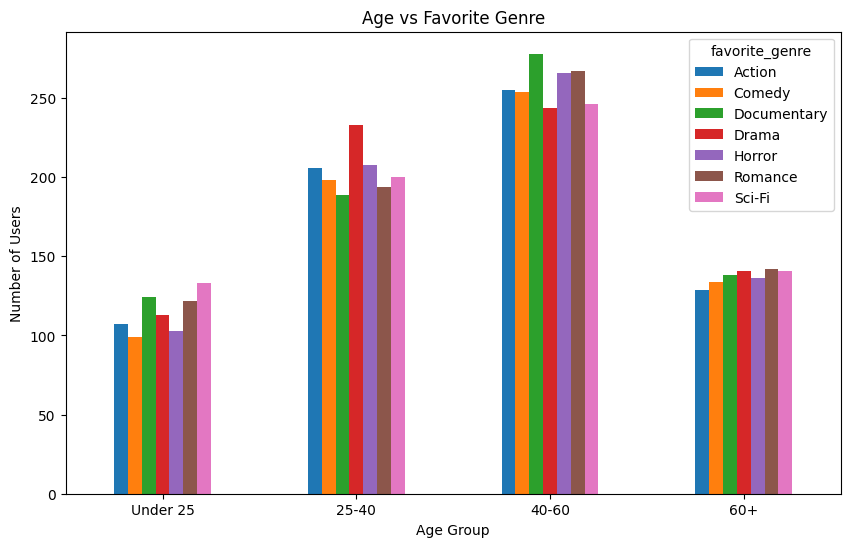

In [15]:
age_genre = pd.crosstab(df['age_group'], df['favorite_genre'])

age_genre.plot(kind='bar', figsize=(10,6))

plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.title("Age vs Favorite Genre")

plt.xticks(rotation=0)
plt.show()

Key Problems Identified

Based on the exploratory analysis of customer behavior, a few important challenges become evident:

1. Limited Difference in Engagement Across Subscription Plans

Although users are spread across Basic, Standard, and Premium plans, their overall watch hours are quite similar. This suggests that higher subscription tiers do not always lead to noticeably higher engagement.

2. Presence of Extreme Viewing Behavior

Some users show unusually high watch hours across all subscription types. While this reflects binge-watching behavior, it can skew average metrics and should be handled carefully during analysis.

3. No Clear Dominance of a Single Genre

User preferences are distributed across multiple genres rather than being concentrated in one or two categories. This makes it difficult to push a single genre-based strategy for all users.

4. Account Sharing Impact

The presence of multiple profiles under a single account indicates frequent account sharing. This can reduce the accuracy of personalized recommendations, as viewing behavior may represent more than one user.

5. Variation in Preferences Across Demographics

Differences in genre choices across age groups and genders highlight that a one-size-fits-all content strategy may not be effective for all users.

Recommendations

Based on the observed patterns and challenges in user behavior, the following actions are recommended:

1. Enhance Value Proposition Across Subscription Plans

Since engagement levels appear similar across subscription tiers, additional incentives or exclusive features could be introduced to better differentiate higher-tier plans and encourage upgrades.

2. Handle Extreme Usage Behavior Carefully

Users with unusually high watch hours should be analyzed separately. Applying outlier treatment techniques or segmentation strategies can prevent distortion of key metrics.

3. Strengthen Personalized Content Strategies

As no single genre dominates user preferences, recommendation systems should continue focusing on individualized content suggestions rather than generalized genre promotion.

4. Improve Personalization for Shared Accounts

Given the prevalence of multiple profiles per account, implementing stronger profile-level tracking and personalization mechanisms can help maintain recommendation accuracy.

5. Adopt Demographic-Aware Targeting

Clear differences in genre preferences across age groups and genders suggest opportunities for demographic-driven content curation and marketing strategies.

Conclusion

The exploratory data analysis highlights that user engagement and content preferences are influenced by a combination of behavioral and demographic factors. While overall usage patterns remain broadly consistent across subscription tiers, notable variations emerge in genre preferences and viewing behavior. These findings emphasize the importance of personalization, targeted content strategies, and careful handling of user heterogeneity to improve platform performance and user satisfaction.